# Titanic — Survival Prediction

Predicting which passengers survived the sinking of the RMS Titanic (15 April 1912), using the Kaggle competition dataset.

- **Train set:** 891 passengers, labelled
- **Test set:** 418 passengers, unlabelled
- **Task:** binary classification — `Survived` ∈ {0, 1}
- **Base rate:** ~38% of passengers in the train set survived

---

## The Features

### `Survived` — target
0 = died, 1 = survived.

### `Pclass` — ticket class (1, 2, 3)
Proxy for socio-economic status, but also for *physical location on the ship*. Third-class cabins sat lower and further from the boat deck. Is expected to be one of the strongest predictors.

### `Sex`
Almost certainly the single strongest predictor. The evacuation followed a "women and children first" protocol, so I expect a large gap between male and female survival — and I expect most of the interesting modelling work to be about *where that protocol broke down*.

### `Age` — ~20% missing
Children were prioritised, so young passengers should survive at a higher rate. The missingness is a problem: with a fifth of the column gone, and the gaps likely concentrated in third class, imputing with a single global median would be misleading. `Name` can help here (see below). Whether a value is missing at all may itself be informative.

### `SibSp` — siblings + spouse aboard
### `Parch` — parents + children aboard
Both count relatives **on the ship**, not total family. Summed together (+1 for the passenger) they give family size. I don't expect a simple linear effect: travelling alone and travelling in a very large group may both be disadvantages, for different reasons.

### `Fare`
Price paid for the **whole ticket**, not per person — a family sharing one ticket shows the same total on every row. It also contains zeros, which are probably employees or guests rather than missing data. Fare should carry information that `Pclass` alone flattens: the difference between a cheap and an expensive first-class cabin.

### `Cabin` — ~77% missing
The intuition is that having a recorded cabin implies money implies a better chance. The catch is that cabins were mostly recorded *for first class*, so this may be little more than a restatement of `Pclass`. Worth checking rather than assuming. The leading letter is the deck, which is a more genuinely spatial piece of information.

### `Embarked` — port of boarding
`S` Southampton, `C` Cherbourg, `Q` Queenstown. Any survival differences between ports are probably explained by the class mix boarding at each. I'd treat an apparent `Embarked` effect as a confound until shown otherwise.

### `Name`
Not usable directly, but it contains an honorific. **Master** means a boy under roughly 13 — the most reliable age signal in the dataset, and one that survives the missingness in `Age`.

### `Ticket`
Looks like an identifier, but tickets were **shared between people travelling together** — families, but also friends, servants, and employers. Group size derived from the ticket captures relationships that `SibSp` and `Parch` cannot.

### `PassengerId`
A sequential row index. Carries no information.

---

## What I Expect to Find

1. `Sex` dominates, and a "predict all women survive" rule sets a surprisingly high baseline that any model has to beat.
2. `Pclass` and `Sex` interact — I expect the "women and children first" protocol to have been applied much more effectively in first class than in third.
3. The child effect will show up more clearly in the `Master` title than in the `Age` column.
4. `Cabin` will turn out to be largely redundant with `Pclass`.
5. Family size will have a non-linear relationship with survival.

The point of the EDA below is to test these, and to write down which ones turn out to be wrong.

In [58]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier


from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV

In [59]:
train_df = pd.read_csv("data/train.csv")

test_df = pd.read_csv("data/test.csv")

In [60]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [61]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [62]:
train_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [63]:
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(train_df[col].value_counts(dropna=False), '\n')

Survived
0    549
1    342
Name: count, dtype: int64 

Pclass
3    491
1    216
2    184
Name: count, dtype: int64 

Sex
male      577
female    314
Name: count, dtype: int64 

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64 



In [64]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [65]:
print(train_df['PassengerId'].is_unique)   
print(train_df.duplicated().sum())

True
0


In [66]:
train_df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])

,sum,count,mean
Sex,,,
female,233,314,0.742038
male,109,577,0.188908


In [67]:
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=range(0, 90, 10))

train_df.groupby('AgeGroup', observed=True)['Survived'].agg(['sum', 'count', 'mean'])

,sum,count,mean
AgeGroup,,,
"(0, 10]",38,64,0.593750
"(10, 20]",44,115,0.382609
"(20, 30]",84,230,0.365217
"(30, 40]",69,155,0.445161
"(40, 50]",33,86,0.383721
"(50, 60]",17,42,0.404762
"(60, 70]",4,17,0.235294
"(70, 80]",1,5,0.200000


In [68]:
train_df.groupby(['Sex', 'AgeGroup'], observed=True)['Survived'].agg(['sum', 'count', 'mean'])

sum  count      mean
Sex    AgeGroup                      
female (0, 10]    19     31  0.612903
       (10, 20]   34     46  0.739130
       (20, 30]   61     81  0.753086
       (30, 40]   46     55  0.836364
       (40, 50]   21     31  0.677419
       (50, 60]   13     14  0.928571
       (60, 70]    3      3  1.000000
male   (0, 10]    19     33  0.575758
       (10, 20]   10     69  0.144928
       (20, 30]   23    149  0.154362
       (30, 40]   23    100  0.230000
       (40, 50]   12     55  0.218182
       (50, 60]    4     28  0.142857
       (60, 70]    1     14  0.071429
       (70, 80]    1      5  0.200000

In [69]:
train_df.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean'])

,sum,count,mean
Pclass,,,
1,136,216,0.629630
2,87,184,0.472826
3,119,491,0.242363


In [70]:
train_df.groupby(['Sex', 'Pclass'])['Survived'].agg(['count', 'mean']).unstack()

count                mean                    
Pclass     1    2    3         1         2         3
Sex                                                 
female    94   76  144  0.968085  0.921053  0.500000
male     122  108  347  0.368852  0.157407  0.135447

In [71]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df.groupby('FamilySize')['Survived'].agg(['count', 'mean'])

,count,mean
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


In [72]:
train_df.groupby('Embarked')['Survived'].agg(['count', 'mean'])

,count,mean
Embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


In [73]:
pd.crosstab(train_df['Embarked'], train_df['Pclass'], normalize='index')

Pclass,1,2,3
Embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [74]:
pd.crosstab(train_df['Cabin'].notna(), train_df['Pclass'], normalize='columns')

Pclass,1,2,3
Cabin,,,
False,0.185185,0.913043,0.97556
True,0.814815,0.086957,0.02444


In [78]:
train_df['Title'] = train_df['Name'].str.extract(r',\s*([^\.]+)\.')
train_df.groupby('Title')['Survived'].agg(['sum', 'count', 'mean']).sort_values('count', ascending=False)

,sum,count,mean
Title,,,
Mr,81,517,0.156673
Miss,127,182,0.697802
Mrs,99,125,0.792000
Master,23,40,0.575000
Dr,3,7,0.428571
Rev,0,6,0.000000
Major,1,2,0.500000
Col,1,2,0.500000
Mlle,2,2,1.000000


In [76]:
train_df['Ticket'].value_counts().head(10)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
Name: count, dtype: int64

In [79]:
train_df[train_df['Fare'] == 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FamilySize,Title
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,"(30.0, 40.0]",1,Mr
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,"(30.0, 40.0]",1,Mr
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,"(20.0, 30.0]",1,Mr
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Mr
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,"(10.0, 20.0]",1,Mr
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Mr
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Mr
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,NaN,1,Mr
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,"(40.0, 50.0]",1,Mr
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S,NaN,1,Mr


<Axes: >

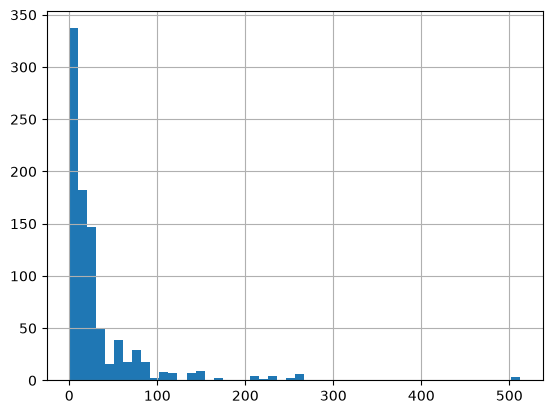

In [80]:
train_df['Fare'].hist(bins=50)

---

## What the Data Showed

| # | Hypothesis | Verdict | Evidence |
|---|---|---|---|
| 1 | `Sex` dominates | Confirmed | 74.2% female vs 18.9% male |
| 2 | `Sex × Pclass` interaction | Confirmed | Female survival: 96.8% → 92.1% → **50.0%** |
| 3 | `Master` beats `Age` as child signal | Partly | See below |
| 4 | `Cabin` redundant with `Pclass` | Confirmed | 81.5% of 1st class have a cabin; 2.4% of 3rd |
| 5 | Family size non-linear | Confirmed | 30% alone → 72% at size 4 → 0% at size 8+ |
| 6 | `Embarked` is a confound | Confirmed | 50.6% of Cherbourg passengers were 1st class |

### 1 & 2 — Sex, and where the protocol broke down

The `Sex × Pclass` table is the dataset in six numbers. Female survival barely moves between 1st and 2nd class (96.8% → 92.1%), then falls off a cliff in 3rd (50.0%). Male survival is low everywhere and its class gradient is much shallower (36.9% → 15.7% → 13.5%).

So "women and children first" was real, but it was a *first- and second-class* protocol. A third-class woman had roughly the same chance as a first-class man. Any model that treats `Sex` and `Pclass` as independent additive effects will get this wrong.

Baseline to beat: predicting "all women survive, all men die" gets **78.7%** accuracy on the train set. That is the number every model must clear.

### 3 — The child signal is weaker than expected

Raw `Age` shows the effect: the 0–10 bin survives at 59.4% against a 38.4% base rate, and it is the only bin materially above it. Everything from 10 to 60 sits flat around 0.37–0.45. Age does almost nothing except identify children.

But **the hypothesis was too strong.** `Master` survives at 57.5% (n=40) — far above `Mr` at 15.7%, so it clearly recovers the child effect. Yet boys aged 0–10 in the raw `Age` column survive at 57.6% (n=33), which is essentially identical. `Master` is not *better* than `Age` here; it is **equally good and available for the ~20% of rows where `Age` is missing.** That is the real argument for using it — coverage, not accuracy.

The finding that does hold: `Title` is the right variable to *impute* `Age` from, because it partitions the population by age and marital status simultaneously.

### 4 — Cabin is Pclass in disguise

81.5% of first-class passengers have a recorded cabin; 8.7% of second and 2.4% of third do. `HasCabin` is close to an indicator for `Pclass == 1` and should not be presented as independent evidence of anything. The **deck letter** may still carry spatial information, but with 687 missing values it will be thin.

The correct interpretation is that this is a *record-keeping* artefact, not a fact about the ship. Everyone had somewhere to sleep. Only first class had it written down.

### 5 — Family size is a hump, not a line

| FamilySize | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 11 |
|---|---|---|---|---|---|---|---|---|---|
| survival | 0.30 | 0.55 | 0.58 | 0.72 | 0.20 | 0.14 | 0.33 | 0.00 | 0.00 |
| n | 537 | 161 | 102 | 29 | 15 | 22 | 12 | 6 | 7 |

Rises to a peak at 4, then collapses. Encoding this as a single continuous variable would force a linear model to average the two halves into nothing. Bin it: `Alone` (1), `Small` (2–4), `Large` (5+).

Caveat: the tail cells are tiny. FamilySize 8 has n=6 and FamilySize 11 has n=7 — the 0.00 survival rates there are six and seven people, not a law of nature. The `Large` bin as a whole (n=62, ~16% survival) is the defensible claim.

### 6 — Embarked explains nothing on its own

Cherbourg's higher survival rate (55.4% vs Southampton's 33.7%) is not about the port. Half of Cherbourg's passengers boarded in first class; 93.5% of Queenstown's boarded in third. `Embarked` is measuring `Pclass` through a proxy. If it shows up as important in a feature-importance plot later, that is a reason to be suspicious of the plot, not to believe the feature.

### Things I did not predict

**Fare has 15 zeros, all male, all boarded at Southampton.** Several share ticket `LINE` or consecutive ticket numbers (`239853`, `239854`). Among them is **Thomas Andrews Jr** — the ship's designer, who died. These are employees of the White Star Line and its suppliers, travelling on company business, not passengers who happened to pay nothing. 14 of 15 died. This is a real category, and `Fare == 0` deserves its own flag rather than being imputed away.

**`Fare` is a total, and the data proves it.** Ticket `347082` appears 7 times — the Andersson family, all with identical `Fare`. There are only 681 unique tickets across 891 rows, so roughly a quarter of passengers share a ticket with someone. Per-person fare requires dividing by group size, computed across train *and* test together, since families are split between the files.

**`Fare` is extremely right-skewed.** Median 14.45, max 512.33. Log-transform before feeding it to anything distance-based.

**Old age is dangerous, and it's not just class.** The 60–70 bin survives at 23.5% and 70–80 at 20.0%, both well below the base rate — despite older passengers skewing wealthier. Small samples (n=17, n=5), so hold this loosely.

**`Rev` went 0 for 6.** Every clergyman aboard died. Almost certainly not a causal feature; almost certainly a story.

### Decisions carried into preprocessing

- Extract `Title` from `Name`; collapse rare titles (`Dr`, `Rev`, `Col`, `Major`, `Capt`, `Sir`, `Lady`, `Countess`, `Jonkheer`, `Don`) into `Rare`; map `Mlle`/`Ms` → `Miss`, `Mme` → `Mrs`.
- Impute `Age` by median within `Title × Pclass`, **not** a global median.
- Add `AgeIsMissing` as a feature.
- Build `FamilySize`, then bin into `Alone` / `Small` / `Large`. Keep `IsAlone` separately.
- Compute ticket-group size across the concatenated train + test sets. Derive `FarePerPerson = Fare / TicketGroupSize`.
- Log-transform `Fare` (`np.log1p`).
- Add `IsZeroFare` flag.
- Impute the 2 missing `Embarked` values. Both are 1st class, £80, cabin `B28`, sharing ticket `113572` — infer from comparable passengers rather than filling with the mode `S`.
- Drop `Cabin` as a direct feature; keep `HasCabin` only to demonstrate its redundancy, and test `Deck` separately.
- Drop `PassengerId`, `Name`, `Ticket` from the feature matrix once their derived features are extracted.
- Explicitly model the `Sex × Pclass` interaction for any linear model. Tree models will find it unaided.

### A note on where this is going

Nearly all the signal above lives in `Sex`, `Pclass`, and `Title`. The remaining features add refinement at the margin. A realistic ceiling on this dataset is around 0.80 on the leaderboard, against a 0.787 baseline from a single `if` statement — the gap is narrow, and most of the work from here is about not making it worse.